In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
# import joblib as jl
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Bike Share Usage Regression — Model Development & Selection

This project uses a [Bike Share Hour dataset](https://raw.githubusercontent.com/arjayit/cs4432_data/master/bike_share_hour.csv) (17,379 records) to build and compare regression models predicting hourly bike share usage (`cnt`). The pipeline covers exploratory data analysis, data preparation, feature encoding, baseline model training, hyperparameter tuning, model selection, and permutation feature importance evaluation.

---

## Pipeline Overview

**1. Exploratory Data Analysis**
17,379 rows × 17 columns spanning 2011–2012 (731 unique dates: 365 + 366 days). No missing values detected; 17,379 rows reported vs. 17,544 expected — 165 hours omitted for zero ridership. ~90% of dates (655/731) carry all 24 hours. Identified 8 categorical features (`season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`). Discovered a README error: each season maps to 4 months (astronomical calendar) rather than 3. Key visualization findings: usage peaks in summer, during commute hours (7–9 AM, 4–7 PM) on working days, under clear conditions, and across the warmer months (June–September).

**2. Data Preparation**
- Dropped `instant` and `dteday` (identifier/descriptive columns)
- Correlation analysis: `casual` (r ≈ 0.695), `registered` (r ≈ 0.972), and `atemp` (r ≈ 0.988 with `temp`) removed to eliminate leakage and multicollinearity
- Split: 67% training (11,643 rows) / 33% testing (5,736 rows), `random_state=415`
- `OneHotEncoder(drop="first")` + `StandardScaler` via `ColumnTransformer` → (11,643 × 52) training array

**3. Initial Model Training**
Evaluated four default regressors — `LinearRegression`, `Lasso`, `DecisionTreeRegressor`, `RandomForestRegressor` — using 5-fold `cross_validate` with R², RMSE, and MAE scoring. The default `RandomForestRegressor` led with RMSE ≈ 57.24 and R² ≈ 0.899; linear models trailed at RMSE ≈ 102–108.

**4. Hyperparameter Tuning**
Applied `GridSearchCV` (5-fold, RMSE scoring) to each regressor:
- **Lasso** — searched `alpha` (50 log-spaced values, 10⁻⁴–10²), `fit_intercept`, and `positive` → optimal `alpha` ≈ 0.012, RMSE ≈ 101.69
- **Decision Tree** — searched `max_depth` and `min_samples_leaf` (np.arange(1, max_depth + 3)) → optimal: `max_depth=24`, `min_samples_leaf=3`, RMSE ≈ 74.78
- **Random Forest** — searched `max_features` [0.5–1.0] × `n_estimators` [100–1000] → optimal: `max_features=0.9`, `n_estimators=1000`, RMSE ≈ 56.80. `max_depth` was intentionally excluded: bagging and ensemble averaging inherently suppress the variance that depth constraints address in a single tree.

**5. Model Selection**
Selected the tuned `RandomForestRegressor` (RMSE ≈ 56.80). The tuned Lasso offered negligible improvement over default `LinearRegression` (~101.69 vs. ~101.70), implying near-optimal regularization at the default alpha for this feature space. One-hot encoding was retained over ordinal encoding, as the dataset's non-hierarchical, binary-decision-driven structure does not support an ordinal ranking assumption.

**6. Feature Importance**
Permutation importance evaluated on the held-out test set (`neg_root_mean_squared_error`, 10 repeats). Temperature, hour-of-day, `workingday`, humidity, and season emerged as the dominant contributors — consistent with the EDA findings. One-hot encoding distributes importance across individual binary indicator columns rather than grouping by original feature.

# Part 1 - Data Importation and Exploration

In [59]:
url = "https://raw.githubusercontent.com/arjayit/cs4432_data/master/bike_share_hour.csv"

df = pd.read_csv(url)

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Part 1(b) - Data Set Dimensions

In [60]:
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

This dataset has 17379 rows and 17 columns.


## Part 1(c) - Unique Dates Present

### Part 1(c)(i) - Number of Unique Dates Present

In [61]:
print(f'This dataset has {df['dteday'].nunique()} unique date labels present.')

This dataset has 731 unique date labels present.


### Part 1(c)(ii) - Evaluation of expected 'dteday' values

The 731 unique date labels agrees with the fact that 2012 was a leap year with 366 days on top of 2011's 365 days. Two standard years with 365 days each would yield a total of 730 days. 

## Part 1(d) - Missing Values

### Part 1(d)(i) - Calculating missing values

In [62]:
def present_missing_val(dataframe):
    '''Calculates and presents the number and percentage of missing values'''

    missing_val = []

    missing_val_count = dataframe.isnull().sum()
    missing_val_percent = ((dataframe.isnull().sum() / len(dataframe)) * 100)

    missing_val.append({
        'Missing val count' : missing_val_count,
        'Missing val percentage' : missing_val_percent
    })

    missing_val_df = pd.DataFrame(missing_val)

    return missing_val_df

present_missing_val(df)


,Missing val count,Missing val percentage
0,instant 0 dteday 0 season ...,instant 0.0 dteday 0.0 season ...


### Part 1(d)(ii) - Calculation of expected rows with respect to hourly reports

In [63]:
def expected_vs_reported_calc(dataframe, **kwargs):
    '''Calculates reported vs. expected rows with respect to hourly reports'''

    expected_vs_reported = []

    reported_rows = dataframe.shape[0]
    
    hours_per_day = kwargs.get('hours_per_day', 24)
    days_of_2011 = kwargs.get('days_of_2011', 365)
    days_of_2012 = kwargs.get('days_of_2012', 366)
    
    expected_rows = ((days_of_2011 + days_of_2012) * hours_per_day)

    expected_vs_reported.append({
        'hours_per_day' : hours_per_day,
        'days_of_2011' : days_of_2011,
        'days_of_2012' : days_of_2012,
        'expected_rows' : expected_rows,
        'reported_rows' : reported_rows
    })

    expected_vs_reported_df = pd.DataFrame(expected_vs_reported)
    
    if reported_rows > expected_rows:
        print(f'The reported rows are more than expected based on the logic below.')
    elif reported_rows < expected_rows:
        print(f'The reported rows are fewer than expected based on the logic below.')
    else:
        print(f'The reported rows show to be accurate based on the logic below.')

    return expected_vs_reported_df 

expected_vs_reported_calc(df, hours_per_day = 24, days_of_2011 = 365, days_of_2012 = 366, years_reported = 2)

The reported rows are fewer than expected based on the logic below.


,hours_per_day,days_of_2011,days_of_2012,expected_rows,reported_rows
0,24,365,366,17544,17379


### Part 1(d)(iii) - Assessment of expected rows vs reported

Despite 17544 rows being calculated, only 17379 rows were reported. This indicates missing hourly records or omission of hours in which there was zero ridership.

### Part 1(d)(iv) - Calculation and presentation of each 'dteday' value in the data

In [64]:
df['dteday'].value_counts(dropna=False)

dteday
2012-12-31    24
2011-01-01    24
2012-12-30    24
2012-12-29    24
2012-12-28    24
              ..
2011-01-26    16
2011-01-18    12
2012-10-30    11
2011-01-27     8
2012-10-29     1
Name: count, Length: 731, dtype: int64

### Part 1(d)(v) - Calculation and presentation of each hour value in the data

In [65]:
hours_per_date = df['dteday'].value_counts(dropna=False)
print(hours_per_date.value_counts())

count
24    655
23     62
22      6
18      2
17      1
16      1
12      1
11      1
8       1
1       1
Name: count, dtype: int64


## Part 1(e) - Input Feature Data Types

In [66]:
df.info()
categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Part 1(f) - Find the error in the README file

### Part 1(f)(i) - Matching months to seasons

In [67]:
print(df.groupby('season').mnth.unique())

season
1      [1, 2, 3, 12]
2       [3, 4, 5, 6]
3       [6, 7, 8, 9]
4    [9, 10, 11, 12]
Name: mnth, dtype: object


### Part 1(f)(ii) - Matching months to seasons

The README file shows four different seasons, which suggests that each season holds three different months. However, by running a groupby function, we see that each season actually holds four different months--suggesting there is some overlap between certain days of the month and the seasons. This is due to the fact that seasons are typically recorded using two different systems: astronomical and meteorological. Using the former, seasons can begin mid-month, aligning with equinoxes and solstices. Using the latter, seasons align with temperature cycles, beginning on the first of the month. 

## Part 1(g) - Descriptive Statistics

### Part 1(g)(i) - Presentation of numerical feature descriptive statistics

In [68]:
numerical_input_features = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

df[numerical_input_features].describe()

,temp,atemp,hum,windspeed,casual,registered
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869
std,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286
min,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000
50%,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000
75%,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000
max,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000


### Part 1(g)(ii) - Presentation of numerical feature descriptive statistics

As established in Part 1(d)(v), the target variable 'cnt' has a minimum val of 1.0, which is logically sound. The dataset omits hours in which no bike rides were recorded.

Regarding 'temp', 'atemp', 'hum', and 'windspeed', these features have all been normalized, which checks out against the dataset characteristics reported in the README. However, only 'temp', 'atemp', and 'hum' have max vals of 1.0; 'windspeed' has a max of 0.8507. Conversely, all features apart from 'cnt' and 'temp' have min values of 0.0. 'Temp' has a min value of 0.02.  

With regard to the user categories, 'casual' has a mean of ~35.68 and 'registered' has a mean of ~153.79, indicating a significant portion of this dataset are registered users. In theory, registered users are more likely to report their personal data (i.e., registration), which naturally makes them the backbone of this dataset.

## Part 1(h) - Visualizations

### Part 1(h)(i) - Cnt vs. season bar plot

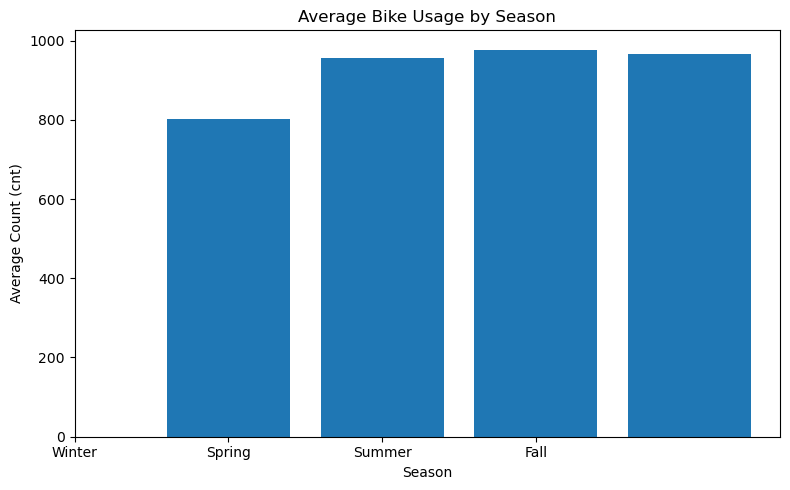

In [69]:
def generate_plot(dataframe, **kwargs):
    '''Generates specified plot based on kwargs'''

    width = kwargs.get('width')
    height = kwargs.get('height')
    title = kwargs.get('title')
    x = kwargs.get('x')
    y = kwargs.get('y')
    hue = kwargs.get('hue', None)
    plot_type = kwargs.get('plot_type', None)
    bins = kwargs.get('bins', None)
    xticks = kwargs.get('xticks', None)
    xtick_labels = kwargs.get('xtick_labels', None)
    xlabel = kwargs.get('xlabel')
    ylabel = kwargs.get('ylabel')
    rotation = kwargs.get('rotation', 'horizontal')

    fig, ax = plt.subplots(figsize=(width, height))

    if plot_type == 'bar':
        ax.bar(data=dataframe, x=x, height=y)
    
    elif plot_type == 'hist':
        ax.hist(data=dataframe, x=x, bins=bins)
        df[x].plot(kind='kde', ax=ax)

    elif plot_type == 'point':
        sns.pointplot(data=dataframe, x=x, y=y, hue=hue, ax=ax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if xticks is not None:
        if xtick_labels is not None:
            ax.set_xticks(ticks=xticks, labels=xtick_labels, rotation=rotation)
        else:
            ax.set_xticks(ticks=xticks)

    plt.tight_layout()
    plt.show()

generate_plot(df, plot_type='bar', width=8, height=5, title='Average Bike Usage by Season', x='season', y='cnt', xlabel='Season', ylabel='Average Count (cnt)', xticks=[0,1,2,3], xtick_labels=['Winter', 'Spring', 'Summer', 'Fall'])

The above bar plot shows higher bike usage during the summer, autumn, and spring months. On average, bike usage was lowest in the Winter and highest during Summer. This goes with my intuition, as I expect bike usage to be generally higher in the warmer seasons than in the winter. Bikers are typically more active in the summer, when they're typically afforded more recreational time and better weather conditions. Additionally, one can expect bikers to be more eager to venture outdoors after being confined inside by episodes of cooler weather. We see a drastic uptick during the transition from Winter to Spring, a peak during Summer, and a slight decline during Fall. With respect to the overlapping months, the fall months begin to cool down. I poured further thought into the reason people commute and made the connection that 'workingday' had a more considerable impact on seasonal biking than anticipated.

### Part 1(h)(ii) - Cnt vs. workingday bar chart

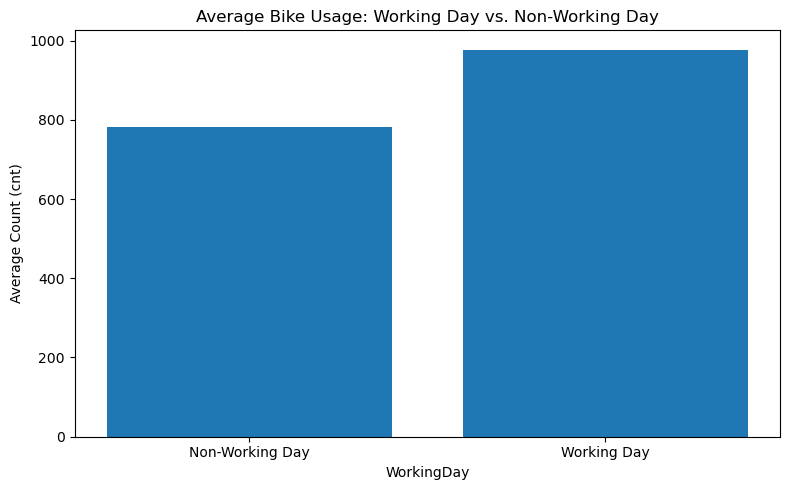

In [70]:
generate_plot(df, plot_type='bar', width=8, height=5, title='Average Bike Usage: Working Day vs. Non-Working Day', x='workingday', y='cnt', xlabel='WorkingDay', ylabel='Average Count (cnt)', xticks=[0,1], xtick_labels=['Non-Working Day','Working Day'])

Bike rides are higher during the working days, which makes sense given that casual and registered bikers are expected to use bikes for either recreational outings or to handle their business (running errands, commuting to work, etc). The distribution of this plot (non-working day vs. working day) leads me to investigate into hourly usage per category, which will be conducted further below. 

### Part 1(h)(iii) - Cnt vs. mnth bar chart

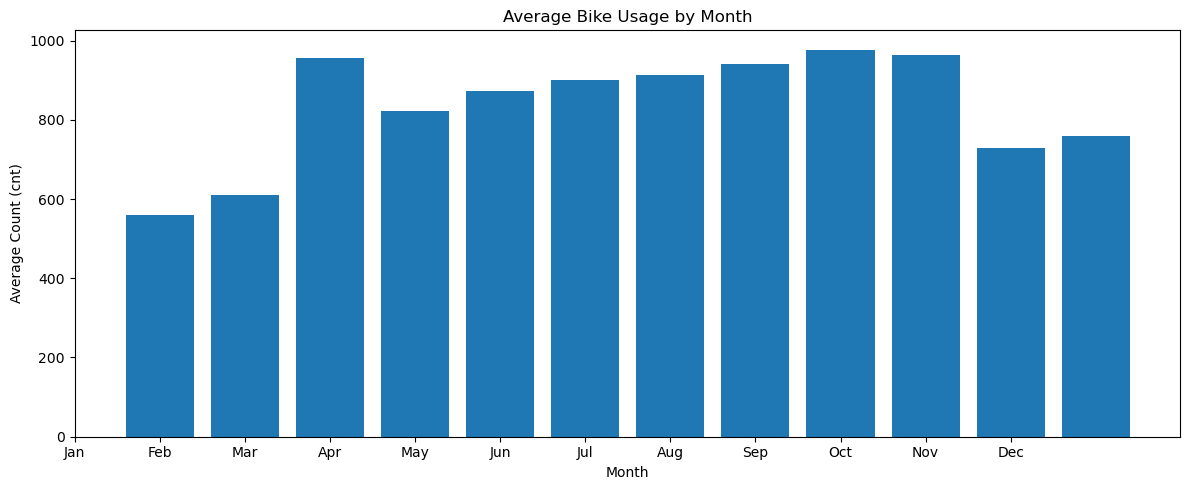

In [71]:
generate_plot(df, plot_type='bar', width=12, height=5, title='Average Bike Usage by Month', x='mnth', y='cnt', xlabel='Month', ylabel='Average Count (cnt)', xticks=np.arange(0,12,1), xtick_labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

This pattern agrees with my intuition, especially after mapping the months to their respective seasons. Bike usage is lowest during December, January, and February (i.e., the cooler months). March marks a significant uptick, with usage increasing as the warmer months approach. June, July, August, and September reflect the highest usage, with usage during May being only slightly higher than October. Again, usage begins to drop considerably during November. 

### Part 1(h)(iv) - Cnt vs. weathersit bar chart 

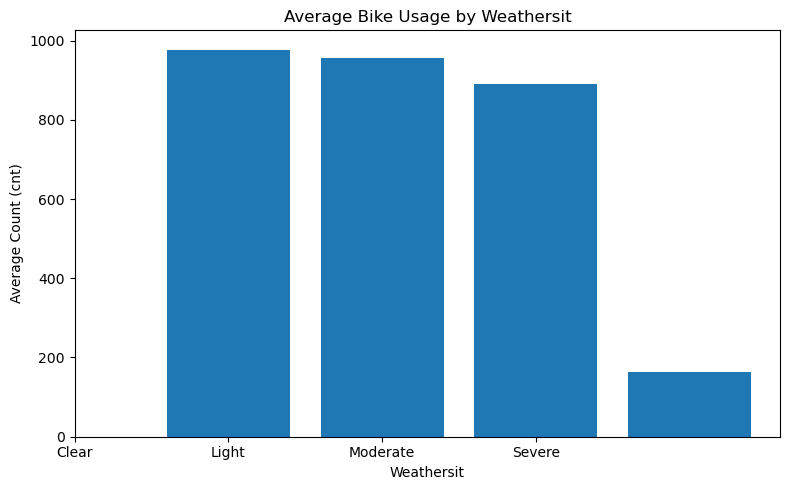

In [72]:
generate_plot(df, plot_type='bar', width=8, height=5, title='Average Bike Usage by Weathersit', x='weathersit', y='cnt', xlabel='Weathersit', ylabel='Average Count (cnt)', xticks=np.arange(0,4,1), xtick_labels=['Clear', 'Light', 'Moderate','Severe'])

The plot above quite clearly shows how weather situations impact bike usage. While bike usage is highest during periods of clear skies and partial cloudiness, users begin to retreat indoors as weather conditions worsen. Bar 2 reflects light weather conditions (e.g., misty weather with heavier clouds), which can be enjoyable but not always so. Bar 3 shows the impact of moderate weather (e.g., snow, light rain, and thunderstorms), which tellingly affect visibility and begin to contribute to safety concerns. Bar 4 reflects, by far, the worst conditions (e.g., heavy rain, ice pellets, thunderstorms, heavy snow, etc.). Obviously, bikers are likely to be taking safety precautions during these conditions, some of which include refraining from biking. 

### Part 1(h)(v) - Cnt vs. weathersit point plot

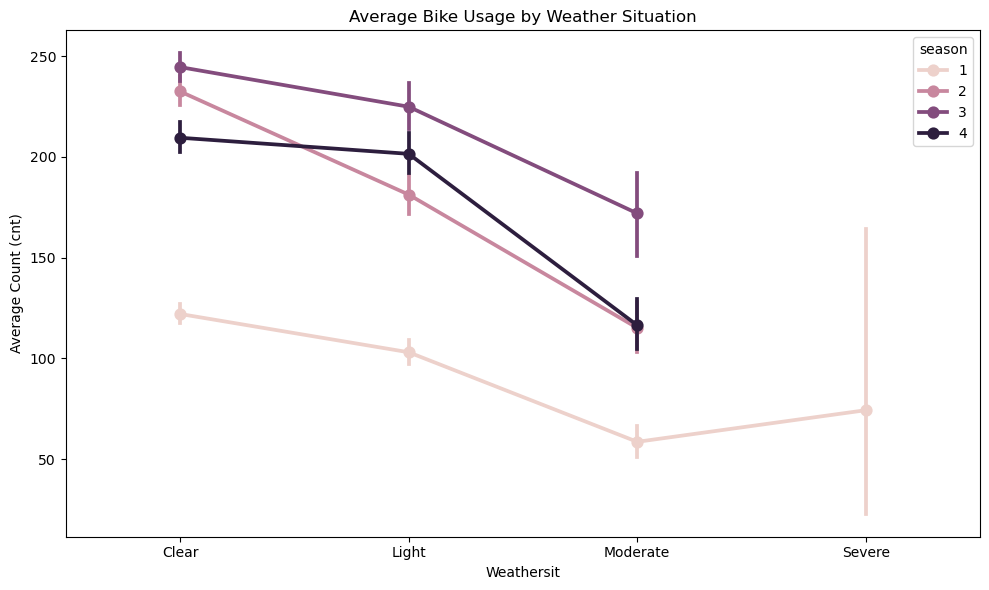

In [73]:
generate_plot(df, plot_type='point', width=10, height=6, title='Average Bike Usage by Weather Situation', x='weathersit', y='cnt', hue='season', xlabel='Weathersit', ylabel='Average Count (cnt)', xticks=np.arange(0,4,1), xtick_labels=['Clear', 'Light', 'Moderate','Severe'])

This point plot reinforces previous observations. Overall, bike usage is lowest during the winter and highest during the summer. For the most part, usage declines as conditions worsen; however, analysis of winter usage tells an interesting story with regard to weather situations 3 and 4. Whereas, one would expect usage to be higher during moderate weather conditions (situation 3), usage is visibly higher during situation 4 (i.e., heavy rain, ice pellets, thunderstorms, etc.). Similarly, winter is the only season in which weather situations approach category 4. This suggests that while category 4 is reserved for the worst weather conditions, the conditions are not as bad as presumed. Heavy rain, though precarious, still permits riding. This leads me to question the distribution of casual and registered riders in the winter, especially during category 4. I imagine that registered riders are more reliant upon bike transportation and subsequently have a higher count during category 4 weather conditions, as opposed to casual riders who are riding recreationally. Duty calls, after all.

### Part 1(h)(vi) - Cnt vs. workingday == 1 bar plot

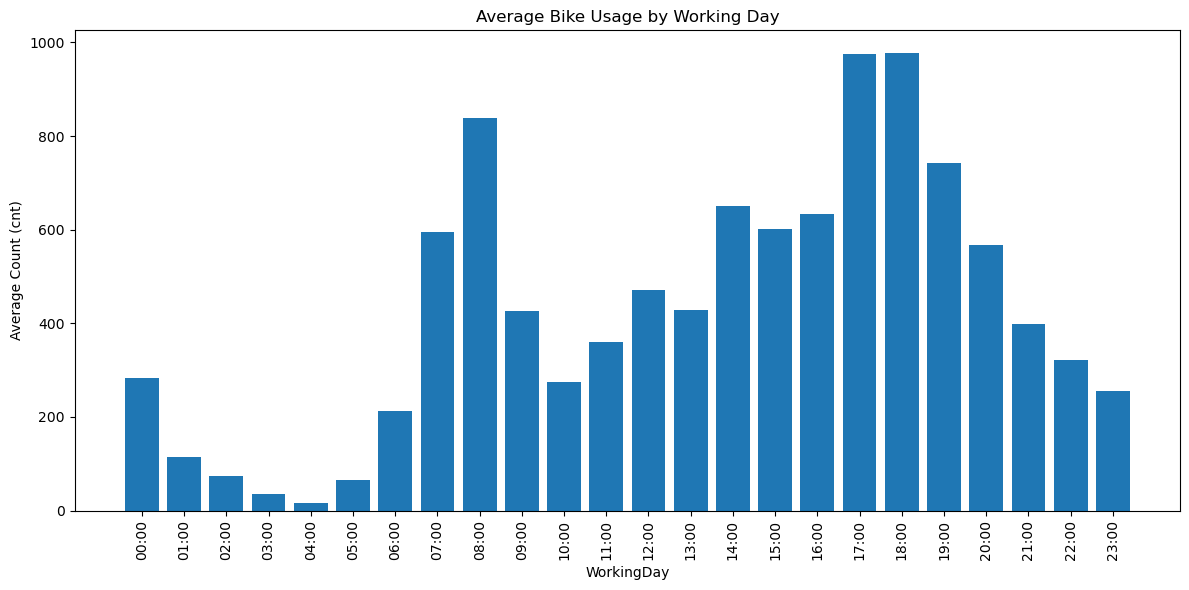

In [74]:
generate_plot(df[df['workingday']==1], plot_type='bar', width=12, height=6, title='Average Bike Usage by Working Day', x='hr', y='cnt', xlabel='WorkingDay', ylabel='Average Count (cnt)', xticks=np.arange(0,24,1), xtick_labels=pd.date_range(start='00:00', end='23:00', freq='h').strftime('%H:%M').tolist(), rotation='vertical')

This plot shows how rider counts are affected throughout the workday. Counts are highest during the morning (i.e., 7am-9am, with 8am being the morning peak) and evenings (i.e., 4pm-7pm, with 5pm being the evening peak), when riders are commuting either to or from work. One might presume registered riders to compose the bulk of these counts. During the afternoons (10am-3pm) and nights (8pm-11pm), riders are less active. Activity is lowest in the early mornings (spanning midnight to 6am). Overall, this spread of activity agrees with my intuition.

### Part 1(h)(vii) - Cnt vs. workingday == 0 bar plot

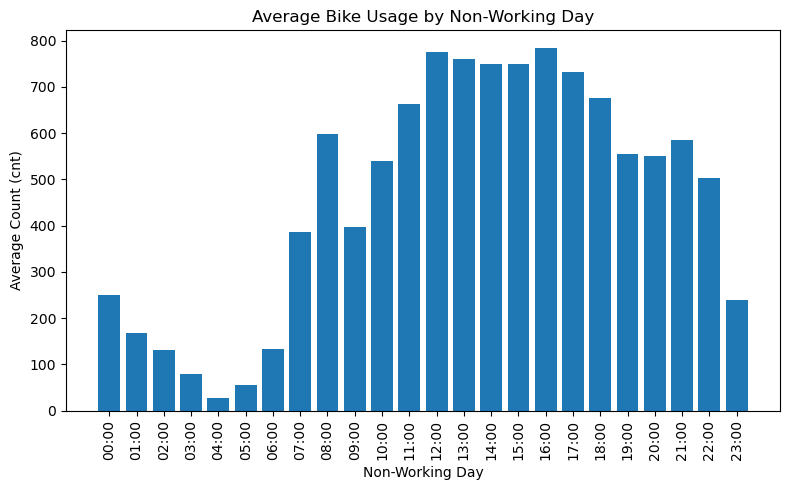

In [75]:
generate_plot(df[df['workingday']==0], plot_type='bar', width=8, height=5, title='Average Bike Usage by Non-Working Day', x='hr', y='cnt', xlabel='Non-Working Day', ylabel='Average Count (cnt)', xticks=np.arange(0,24,1), xtick_labels=pd.date_range(start='00:00', end='23:00', freq='h').strftime('%H:%M').tolist(), rotation='vertical')

This plot shows how rider count fluctuates throughout the non-working day. Interestingly enough, rider counts are much higher throughout the late mornings, afternoons, and evenings. Similar to the working day, usage is lowest during the early mornings. However, of the earlier morning hours, usage is highest around midnight, tapering off from 1am-3am and dropping to the lowest levels from 4am-5am. Usage begins to increase during 6am and continue to do so through the afternoon, with peaks spanning 12pm-4pm. Usage begins to decline visibly around 5pm and continue to do so through the evening and into the late night. Notably, usage holds somewhat steady between 11pm and midnight. 

### Part 1(h)(viii) - Cnt vs. histogram

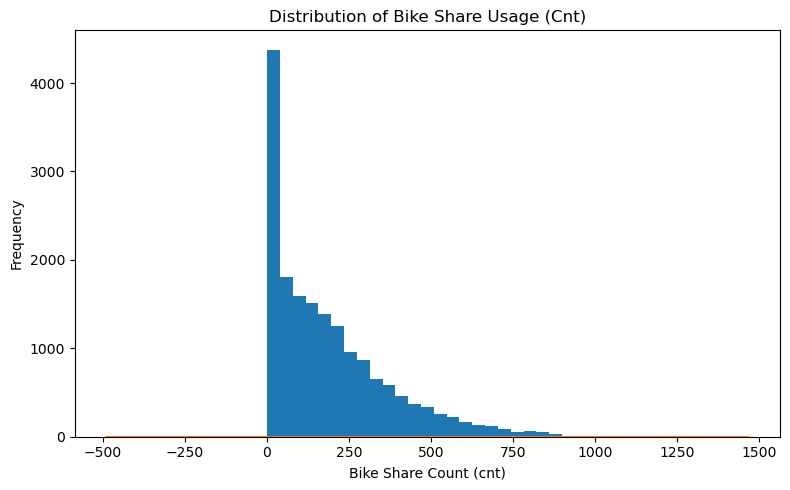

In [76]:
generate_plot(df, plot_type='hist', width=8, height=5, title='Distribution of Bike Share Usage (Cnt)', x='cnt', xlabel='Bike Share Count (cnt)', ylabel='Frequency', bins=25)

The plot shows that ~4300 hours (almost a quarter of the data) sustained between 1-40 rides per hour, indicated by the first bin along the x-axis. Of note, the dataset omits hours in which no rides were recorded, establishing the minimum ride-per-hour count to be 1. Heavier hourly-ride densities were less common, as indicated by the positive skewness. The tail of the plot extends toward the max, ~977 rides. Thus, the peak hours are not nearly as prevalent, serving to be more-or-less outliers.

# Part 2 - Data Prep

## Part 2(a) - Remove the Descriptive Features

In [20]:
def drop_columns(dataframe, *args):
    '''Takes in passed dataframe and arbitrary number of columns to drop specified columns'''

    # drops those columns
    new_df = dataframe.drop(columns=list(args))

    # checks to ensure specified columns were dropped
    assert not any(col in new_df.columns for col in args), f'Error: Target columns found that should have been dropped'

    # visual check of updated dataframe dimensions
    print(f'This updated dataframe has {new_df.shape[0]} rows and {new_df.shape[1]} columns.')
    print(f'Remaining columns: {list(new_df.columns)}')

    return new_df

df = drop_columns(df, 'dteday', 'instant')

This updated dataframe has 17379 rows and 15 columns.
Remaining columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


## Part 2(b) - Correlations

### Part 2(b)(i) - Correlations

In [21]:
df.corr()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
season,1.000000,-0.010742,0.830386,-0.006117,-0.009585,-0.002335,0.013743,-0.014524,0.312025,0.319380,0.150625,-0.149773,0.120206,0.174226,0.178056
yr,-0.010742,1.000000,-0.010473,-0.003867,0.006692,-0.004485,-0.002196,-0.019157,0.040913,0.039222,-0.083546,-0.008740,0.142779,0.253684,0.250495
mnth,0.830386,-0.010473,1.000000,-0.005772,0.018430,0.010400,-0.003477,0.005400,0.201691,0.208096,0.164411,-0.135386,0.068457,0.122273,0.120638
hr,-0.006117,-0.003867,-0.005772,1.000000,0.000479,-0.003498,0.002285,-0.020203,0.137603,0.133750,-0.276498,0.137252,0.301202,0.374141,0.394071
holiday,-0.009585,0.006692,0.018430,0.000479,1.000000,-0.102088,-0.252471,-0.017036,-0.027340,-0.030973,-0.010588,0.003988,0.031564,-0.047345,-0.030927
weekday,-0.002335,-0.004485,0.010400,-0.003498,-0.102088,1.000000,0.035955,0.003311,-0.001795,-0.008821,-0.037158,0.011502,0.032721,0.021578,0.026900
workingday,0.013743,-0.002196,-0.003477,0.002285,-0.252471,0.035955,1.000000,0.044672,0.055390,0.054667,0.015688,-0.011830,-0.300942,0.134326,0.030284
weathersit,-0.014524,-0.019157,0.005400,-0.020203,-0.017036,0.003311,0.044672,1.000000,-0.102640,-0.105563,0.418130,0.026226,-0.152628,-0.120966,-0.142426
temp,0.312025,0.040913,0.201691,0.137603,-0.027340,-0.001795,0.055390,-0.102640,1.000000,0.987672,-0.069881,-0.023125,0.459616,0.335361,0.404772
atemp,0.319380,0.039222,0.208096,0.133750,-0.030973,-0.008821,0.054667,-0.105563,0.987672,1.000000,-0.051918,-0.062336,0.454080,0.332559,0.400929


### Part 2(b)(ii) - Correlation Analysis

Regarding the 'season' feature, the correlations above show 'mnth' to share a strong, positive correlation (~0.83). The 'temp' and 'atemp' features both show a weak to moderate correlation to 'season' ~(0.312, 0.319, respectively). 'Workingday' shows the weakest positive correlation (~0.014), with the 'cnt', 'registered', and 'casual' features showing weak correlations ~(0.178, 0.174, and 0.120, respectively). The 'yr', 'hr', 'holiday', 'weekday', 'weathersit', and 'windspeed' showing weak, negative correlations. 

With regard to the target variable, 'cnt', the 'registered' feature shows both a positive and the strongest correlation (~0.972), followed by the 'casual' feature (~0.695). The 'temp', 'atemp', and 'hr' features show moderate correlation values ~(0.405, 0.401, and 0.394). Though positive, the correlation values of 'season', 'year', 'mnth', 'weekday', 'workingday' and 'windspeed' show the weakest values. All other 'features' are negatively correlated, with 'hum' showing a weak to moderate correlation value (-0.323). 

With respect to the 'casual' users, there lie only three negative correlations, 'humidity', 'workingday' and 'weathersit', each of which being weak ~(-0.347, -0.301, and -0.153). Of the remaining, positive features, 'temp' and 'atemp' show the highest correlation values ~(0.460 and 0.454). 'Cnt' and 'registered' show moderate to strong relationships with values of ~(0.695 and 0.507).

Regarding the 'registered' users, there lie only three negative correlations, 'humidity', 'weathersit', and 'holiday', with values of ~(-0.274, -0.121, and -0.047). 'Cnt' and 'casual' show the strongest positive correlations, with values of ~(0.972 and 0.507). 'Hr', 'temp', and 'atemp' show weak to moderate values of ~(0.374, 0.335 and 0.333). The remaining features show weak, positive relationships with 'yr' reflecting the highest value of this subgroup ~(0.254). 

With respect to their larger correlation values, 'casual', 'registered' and 'atemp' will be removed from the dataset.

## Part 2(b)(iii) - Removal of 'casual', 'registered', and 'atemp' features

In [22]:
df = drop_columns(df, 'casual', 'registered', 'atemp')

numerical_features = ['temp', 'hum', 'windspeed']   

This updated dataframe has 17379 rows and 12 columns.
Remaining columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']


# Part 2(c) - Data Partitioning

In [23]:
def data_partition(dataframe, **kwargs):
    '''Partitions data while reserving 33% for test data, and
     setting a random_state for reproducibility'''

    # saves variables from kwargs
    test_size = kwargs.get('test_size', 0.33)
    random_state = kwargs.get('random_state', 415)
    target_variable = kwargs.get('target_variable', 'cnt')

    # drops target variable and 
    X = dataframe.drop(columns=target_variable)
    y = dataframe[target_variable]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
    )

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = data_partition(df, test_size=0.33, random_state=415, target_variable='cnt')

## Part 2(d) - Encoding Categorical Features

In [24]:
def feature_encoding(training_features, testing_features, categorical_inputs, numerical_inputs, **kwargs):
    '''Encodes features based on specified encoding method (i.e., OneHot or Ordinal)'''

    sparse_output = kwargs.get('sparse_output', False)
    drop_strategy = kwargs.get('drop_strategy', 'first')
    encoding_method = kwargs.get('encoding_method', 'ohe')
    categories = kwargs.get('categories')

    if encoding_method == 'ohe':
        ohe_transformer = ColumnTransformer(transformers=[
            (encoding_method, OneHotEncoder(sparse_output=sparse_output, drop=drop_strategy), categorical_inputs),
            ('scaler', StandardScaler(),                                            numerical_inputs)])

        X_train_one_hot_enc = ohe_transformer.fit_transform(training_features)
        X_test_one_hot_enc = ohe_transformer.transform(testing_features)

        print(f'X_train_oheenc shape: {X_train_one_hot_enc.shape}')
        print(f'X_test_oheenc shape: {X_test_one_hot_enc.shape}')

        return ohe_transformer, X_train_one_hot_enc, X_test_one_hot_enc
    
    elif encoding_method == 'ordinal':
        ordinal_transformer = ColumnTransformer(transformers=[
            (encoding_method, OrdinalEncoder(categories=categories), categorical_inputs),
            ('scaler', StandardScaler(),                            numerical_inputs)])
        
        X_train_ordinal_enc = ordinal_transformer.fit_transform(training_features)
        X_test_ordinal_enc = ordinal_transformer.transform(testing_features)

        print(f'X_train_ordenc shape: {X_train_ordinal_enc.shape}')
        print(f'X_test_ordenc shape: {X_test_ordinal_enc.shape}')

        return ordinal_transformer, X_train_ordinal_enc, X_test_ordinal_enc

ohe_transformer, X_train_ohe_enc, X_test_ohe_enc = feature_encoding(X_train, X_test, categorical_features, numerical_features, encoding_method='ohe', sparse_output=False, drop_strategy='first')

X_train_oheenc shape: (11643, 52)
X_test_oheenc shape: (5736, 52)


# Part 3 - Initial Model Training

## Part 3(a) - Instantiation of regressors

In [25]:
def instantiate_regressors(**kwargs):
    '''Instantiates regressors with appropriate parameters as kwargs'''

    random_state = kwargs.get('random_state', 415)
    max_iter = kwargs.get('max_iter', 100000)

    list_of_algos = [
        (LinearRegression, {}),
        (Lasso, {'max_iter': max_iter}),
        (DecisionTreeRegressor, {'random_state': random_state}),
        (RandomForestRegressor, {'random_state': random_state})   
    ]

    model_list = [model(**params) for model, params in list_of_algos]

    return model_list

models = instantiate_regressors(random_state=415, max_iter=100000)
linear_regressor_default, lasso_regressor_default, decision_tree_default, random_forest_default = models

## Part 3(b) - 5-fold Cross-validation

In [26]:
final_metrics = []

def cross_validation(encoded_training_data, model_list, **kwargs):
    '''Cross validates regressor models using K-fold cross validation'''
    
    metrics = []

    k_fold_param = kwargs.get('k_fold_param', 5)
    encoding_type = kwargs.get('encoding_type', 'OneHot')

    for model in model_list:
        name = f' {model.__class__.__name__} Default'
        print(f'Cross Validation for {name}')

        # cross validation score calculations
        cv_results = cross_validate(estimator=model,
                                X = encoded_training_data,
                                y = y_train,
                                cv = k_fold_param,
                                scoring= ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'])

        r_2_score = cv_results['test_r2']
        rmse_scores = -cv_results['test_neg_root_mean_squared_error']
        mae_scores = -cv_results['test_neg_mean_absolute_error']

        # creating dict to reference for CV dataframe construction
        metrics.append({
            'Algorithm': name,
            'Encoding Method': encoding_type,
            'Avg R^2 Score': r_2_score.mean(),
            'Avg RMSE': rmse_scores.mean(),
            'Avg MAE': mae_scores.mean()
        })

        # list converted to df in part 5 for final model selection
        final_metrics.append({
            'Algorithm': name,
            'Encoding Method': encoding_type, 
            'Avg RMSE': rmse_scores.mean(),
        })

    # constructing dataframe for visualization
    cv_metrics_df = pd.DataFrame(metrics)
    display(cv_metrics_df)

cross_validation(X_train_ohe_enc, models, k_fold_param=5, encoding_type='OneHot')

Cross Validation for  LinearRegression Default
Cross Validation for  Lasso Default
Cross Validation for  DecisionTreeRegressor Default
Cross Validation for  RandomForestRegressor Default


,Algorithm,Encoding Method,Avg R^2 Score,Avg RMSE,Avg MAE
0,LinearRegression Default,OneHot,0.680799,101.704479,75.335575
1,Lasso Default,OneHot,0.641021,107.846680,79.548175
2,DecisionTreeRegressor Default,OneHot,0.793562,81.742289,48.732363
3,RandomForestRegressor Default,OneHot,0.898778,57.242272,36.471774


## Part 3(c) - Cross-validation evaluation

The cross-validation scores show the RandomForestRegressor to be the best performing model. This makes sense given the non-linearity of the dataset and its treatment via OneHot encoding. Realistically, people choose whether to engage in bike rides based on several variables, 'weathersit', 'temp', need (e.g., 'workingday vs. non-working day'), etc. Naturally, these decisions--many of which are binary in nature--enable the DecisionTree and RandomForest regressors to fit better in comparison to the Linear and Lasso Regressors, which are more linear in nature. While we see the DecisionTree and RandomForest Regressors perform better overall, the RandomForest clearly compensates for the limitations of the DecisionTree. Whereas the DecisionTree might overfit to the data and produce higher error when generalized, this study's design capitalizes on this tendency to overfit through implementation of the RandomForest, which compensates for, and minimizes, this error by producing multiple trees.

# Part 4 - Tuning Model Hyperparameters

## Part 4(a) - Lasso GridSearch for Optimal Hyperparameters

In [27]:
def employ_grid_search(estimator, param_grid, x, y, label, **kwargs ):
    '''Initiates a GridSearchCV for models implemented'''

    grid_search_metrics = []

    encoding_method = kwargs.get('encoding_method')
    cv = kwargs.get('cv', 5)
    verbose = kwargs.get('verbose', 0)
    scoring = kwargs.get('scoring', 'neg_root_mean_squared_error')
    refit = kwargs.get('refit', True)
    n_jobs = kwargs.get('n_jobs', -1)

    grid_search = GridSearchCV(estimator=estimator,
                               param_grid=param_grid,
                               cv=cv,
                               verbose=verbose,
                               scoring=scoring,
                               refit=refit,
                               n_jobs=n_jobs
                               )

    grid_search.fit(X=x, y=y)

    best_params = grid_search.best_params_
    best_estimator = grid_search.best_estimator_
    avg_rmse = -grid_search.best_score_

    grid_search_metrics.append({
        'Algorithm': label,
        'Encoding Method': encoding_method,
        'Optimal Params': best_params,
        'Best Estimator': best_estimator,
        'Avg RMSE': avg_rmse
    })

    final_metrics.append({
        'Algorithm': label,
        'Encoding Method': encoding_method,
        'Optimal Params': best_params, 
        'Best Estimator': best_estimator,
        'Avg RMSE': avg_rmse
    })

    # constructing dataframe for visualization
    grid_search_df = pd.DataFrame(grid_search_metrics)
    display(grid_search_df)
    
    return grid_search

lasso_reg_grid = [
    {'fit_intercept': [True, False],
     'positive': [True, False],
     'alpha': np.logspace(-4, 2, 50)}
]

lasso_grid_search = employ_grid_search(lasso_regressor_default, lasso_reg_grid, X_train_ohe_enc, y_train, 'Lasso Regressor Tuned', encoding_method='One Hot', cv=5, verbose=0, scoring='neg_root_mean_squared_error', refit=True, n_jobs=-1)
jl.dump(lasso_grid_search, 'lasso_gs.pkl')

,Algorithm,Encoding Method,Optimal Params,Best Estimator,Avg RMSE
0,Lasso Regressor Tuned,One Hot,"{'alpha': 0.012067926406393288, 'fit_intercept...","Lasso(alpha=np.float64(0.012067926406393288), ...",101.685325


['lasso_gs.pkl']

## Part 4(b) - DecisionTree Optimal Depth Search

In [28]:
optimal_depth_dec_tree = DecisionTreeRegressor(random_state=415)

optimal_depth_dec_tree.fit(X_train_ohe_enc, y_train)
max_depth_one_hot = optimal_depth_dec_tree.get_depth()

print(f'Optimal tree depth (one-hot encoded): {max_depth_one_hot}')

Optimal tree depth (one-hot encoded): 44


## DecisionTree GridSearch for Optimal Hyperparameters

In [29]:
# decisiontree max_depth_one_hot
tree_reg_grid_params_ohe = [
    {'max_depth':np.arange(start=1, stop=max_depth_one_hot + 3, step=1),
     'min_samples_leaf':np.arange(start=1, stop=max_depth_one_hot + 3, step=1)}
]

decision_tree_grid_search = employ_grid_search(decision_tree_default, tree_reg_grid_params_ohe, X_train_ohe_enc, y_train, 'Decision Tree Tuned', encoding_method='One Hot', cv=5, verbose=0, scoring='neg_root_mean_squared_error', refit=True)
jl.dump(decision_tree_grid_search, 'decision_tree_grid_search.pkl')

,Algorithm,Encoding Method,Optimal Params,Best Estimator,Avg RMSE
0,Decision Tree Tuned,One Hot,"{'max_depth': 24, 'min_samples_leaf': 3}","DecisionTreeRegressor(max_depth=np.int64(24), ...",74.784289


['decision_tree_grid_search.pkl']

## Part 4(c) - RandomForest Grid Search

In [30]:
rf_param_grid = [
    {'max_features': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
     'n_estimators': np.arange(100, 1100, 100)}
    ]

rf_grid_search = employ_grid_search(random_forest_default, rf_param_grid, X_train_ohe_enc, y_train, 'Random Forest Max_Features', encoding_method='One Hot', cv=5, verbose=0, scoring='neg_root_mean_squared_error', refit=True)
jl.dump(rf_grid_search, 'rf_grid_search.pkl')

,Algorithm,Encoding Method,Optimal Params,Best Estimator,Avg RMSE
0,Random Forest Max_Features,One Hot,"{'max_features': 0.9, 'n_estimators': 1000}","(DecisionTreeRegressor(max_features=0.9, rando...",56.798995


['rf_grid_search.pkl']

While one might hesitate at the thought of the DecisionTree's tendency to overfit without a specified max_depth, the RandomForest trains using bagging (bootstrapped aggregation) to capitalize on this limitation. Thus, by respecting theory and deploying the RandomForest without a max_depth hyperparameter, each tree fits to the data and becomes a subject-matter expert. With each perturbation to the dataset, the resulting tree in this collection has new insight to offer. This design enables the RandomForest to capitalize by aggregating these outputs to reduce the variance, overcome the limitations of overfitting, and improve prediction performance.

# Part 5 - Model Selection

## Part 5(a) - Optimum Model Selection

In [31]:
final_metrics_df = pd.DataFrame(final_metrics)

display(final_metrics_df.sort_values('Avg RMSE'))

,Algorithm,Encoding Method,Avg RMSE,Optimal Params,Best Estimator
6,Random Forest Max_Features,One Hot,56.798995,"{'max_features': 0.9, 'n_estimators': 1000}","(DecisionTreeRegressor(max_features=0.9, rando..."
3,RandomForestRegressor Default,OneHot,57.242272,NaN,NaN
5,Decision Tree Tuned,One Hot,74.784289,"{'max_depth': 24, 'min_samples_leaf': 3}","DecisionTreeRegressor(max_depth=np.int64(24), ..."
2,DecisionTreeRegressor Default,OneHot,81.742289,NaN,NaN
4,Lasso Regressor Tuned,One Hot,101.685325,"{'alpha': 0.012067926406393288, 'fit_intercept...","Lasso(alpha=np.float64(0.012067926406393288), ..."
0,LinearRegression Default,OneHot,101.704479,NaN,NaN
1,Lasso Default,OneHot,107.846680,NaN,NaN


Based on the RMSE scores shown in the final_metrics_df above, the tuned RandomForest should be selected. While the tuned instantiations of the DecisionTree and the RandomForest showed the lowest average RMSE scores of the models, the tuned RandomForest clearly demonstrates the efficacy of using an aggregation of trees to minimize error (RMSE: ~56.80). 

### Part 5(b)(i) - Comparison of optimal lasso regressor vs. default lasso and linear regressors

With an average RMSE of ~101.69, the tuned lasso regressor performed only slightly better than the default linear regressor (RMSE: ~101.70). However, both of these regressors outperformed the default lasso regressor, which reported an RMSE of ~107.85. Under the hood, the default lasso regressor is likely negating certain features by aggressively reducing their weights to zero; however, the default linear regressor searches to fit the best regression line with respect to the feature weights. On a similar note, the tuned lasso regressor maintains that balance between fitting the regression line while respecting the weights during regularization without negating them.    

### Part 5(b)(ii) - Contemplation of ordinal encoding

This dataset is rather vast, so it might help to assess the models' performances with ordinally encoding data, especially given the inclusion of the DecisionTree and the RandomForest regressors. The Titanic dataset showed that the DecisionTree can outperform other models--apart from the RandomForest, which was not tested using that dataset--given the data's cardinality. However, by ordinally encoding the dataset, the assumption is made that there lies a hierarchical ranking in how bikers choose to rent the bikes. Naturally, whether or not the day is a 'workingday' affects one's need/desire to rent. Features such as 'weathersit', 'temp', 'hum' and 'windspeed' are likely affected by 'season', which implies a hierarchical ranking. Additionally, this dataset capitalizes on the DecisionTree's tendency to overfit through implementation of the RandomForest.

# Part 6 - Feature Importance

## Part 6(a) - Feature Importance Permutation

In [32]:
optimal_model = rf_grid_search.best_estimator_

def feat_importance_calc(**kwargs):
    '''Calculates the feature importance of the optimal model'''
    
    estimator = kwargs.get('estimator')
    X = kwargs.get('X')
    y = kwargs.get('y')
    scoring = kwargs.get('scoring', 'neg_root_mean_squared_error')
    n_repeats = kwargs.get('n_repeats', 10)
    n_jobs = kwargs.get('n_jobs', -1)
    random_state = kwargs.get('random_state', 415)
    feature_names = kwargs.get('feature_names')

    perm_eval=permutation_importance(
        estimator=estimator,
        X=X,
        y=y,
        scoring=scoring,
        n_repeats=n_repeats,
        n_jobs=n_jobs,
        random_state=random_state
    )

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Avg Importance': perm_eval.importances_mean
    }).sort_values('Avg Importance', ascending=False)

    display(importance_df)

    return perm_eval

feat_importance_calc(estimator=optimal_model, X=X_test_ohe_enc, y=y_test, scoring='neg_root_mean_squared_error', n_repeats=10, n_jobs=-1, random_state=415, feature_names=ohe_transformer.get_feature_names_out())    

,Feature,Avg Importance
49,scaler__temp,7.094317e+01
45,ohe__workingday_1,5.529032e+01
31,ohe__hr_17,5.244845e+01
22,ohe__hr_8,5.133417e+01
32,ohe__hr_18,4.606822e+01
3,ohe__yr_1,3.848211e+01
50,scaler__hum,3.394696e+01
33,ohe__hr_19,2.197841e+01
21,ohe__hr_7,1.917784e+01
30,ohe__hr_16,9.334579e+00


{'importances_mean': array([2.91394090e-01, 3.82767298e-01, 6.30305923e+00, 3.84821142e+01,
        2.78509087e-01, 4.79473253e-01, 2.34520676e-01, 1.69318449e-01,
        2.28587813e-01, 3.85938453e-01, 7.35430383e-02, 3.56206894e-01,
        4.51338504e-01, 1.24536241e-01, 4.57663197e-01, 4.70687782e+00,
        5.47768549e+00, 6.33636048e+00, 6.62659128e+00, 4.85964012e+00,
        2.02549043e+00, 1.91778390e+01, 5.13341730e+01, 8.85088469e+00,
        2.55339043e+00, 3.13995161e+00, 4.87301984e+00, 3.32055444e+00,
        2.35304028e+00, 2.56913370e+00, 9.33457943e+00, 5.24484543e+01,
        4.60682197e+01, 2.19784092e+01, 9.06466935e+00, 3.01975551e+00,
        1.63108259e+00, 1.90792330e+00, 2.78107894e-01, 2.53341742e-01,
        1.86837253e-01, 1.01783087e-01, 1.02621096e-01, 1.82016848e+00,
        1.03593841e+00, 5.52903249e+01, 2.60122030e-01, 3.37222915e+00,
        4.27515516e-09, 7.09431748e+01, 3.39469581e+01, 9.12567538e-01]),
 'importances_std': array([6.81917315e-02,

## Part 6(b) - Evaluation of Feature Importance

Evaluation of the input feature importance metrics supports my inclination that weather variables and time-of-day play a significant factor in whether bikers choose to rent. Again, by one-hot encoding the data, the input features are less hierarchical, giving each feature more importance with respect to the non-linearity of the dataset. As shown by the earlier plots, 'temp', 'workingday', hour-of-day, 'hum', 'season', and 'weathersit' all contribute heavily to a biker's need, and subsequently their choice, to rent a bicycle. 'Temp', 'workingday' and hour-of-day reign as the most important input features.

Morning and evening agendas weigh heavily into these decisions, with each being determined by whether or not the day is a working day. Further, a biker will almost certainly factor in external conditions, specifically the temperature. Nobody wants to be uncomfortable during their bike ride, regardless of whether that entails commuting to work, running errands, exercising, or meeting for a date.